# Un semplice transformer da zero

In questo notebook costruiamo un **transformer decoder** in miniatura, componente per componente.
L'architettura è quella di un modello linguistico autoregressivo: dato un prefisso di testo,
il modello impara a predire il token successivo.

Usiamo un corpus sintetico di ricette italiane con vocabolario controllato (~55 token)
per rendere ogni passaggio osservabile e interpretabile.

## Architettura che costruiremo

```
token indices
     │
     ▼
┌─────────────────┐
│ Token Embedding │   ogni token → vettore d_model-dimensionale
└────────┬────────┘
         │  +
┌─────────────────────┐
│ Positional Encoding │   ogni posizione → vettore sommato all'embedding
└────────┬────────────┘
         │
┌────────────────────────┐
│   Transformer Block    │  ×N
│  ┌──────────────────┐  │
│  │ Causal Attention │  │   ogni token guarda solo i token precedenti
│  └──────────────────┘  │
│  ┌──────────────────┐  │
│  │  Feed Forward    │  │   trasformazione non-lineare posizione per posizione
│  └──────────────────┘  │
└────────┬───────────────┘
         │
┌─────────────────────┐
│  Proiezione finale  │   vettore d_model → distribuzione su vocabolario
└─────────────────────┘
```

In questa prima sezione ci occupiamo della base: caricare il corpus,
costruire il vocabolario e preparare i dati per il training.

In [1]:
import json
import torch
from torch.utils.data import Dataset, DataLoader
from pathlib import Path

## 1. Vocabolario e tokenizzatore

Un modello neurale non lavora direttamente con le parole ma con **numeri interi**.
Il tokenizzatore è il componente che traduce tra i due mondi:

- **encode**: stringa → lista di indici interi
- **decode**: lista di indici → stringa

Il vocabolario assegna a ogni token un indice univoco.
Aggiungiamo un token speciale `[PAD]` all'indice 0, usato per portare tutte le sequenze
alla stessa lunghezza durante il training.

```
"scaldate la padella poi versate l'olio ."
     ↓
[47, 26, 40, 43, 52, 29, 0]
```

Il vocabolario del nostro corpus ha 55 token + `[PAD]` = **56 indici** in totale.

In [2]:
class Tokenizer:
    PAD_TOKEN = '[PAD]'
    PAD_IDX = 0

    def __init__(self, vocabulary):
        # [PAD] always occupies index 0
        self.vocab = [self.PAD_TOKEN] + vocabulary
        self.word2idx = {w: i for i, w in enumerate(self.vocab)}
        self.idx2word = {i: w for i, w in enumerate(self.vocab)}

    @property
    def vocab_size(self):
        return len(self.vocab)

    def encode(self, sentence):
        """Sentence string → list of token indices."""
        return [self.word2idx[token] for token in sentence.split()]

    def decode(self, indices, skip_pad=True):
        """List of token indices → sentence string."""
        tokens = [
            self.idx2word[i] for i in indices
            if not (skip_pad and i == self.PAD_IDX)
        ]
        return ' '.join(tokens)

    def pad(self, indices, length):
        """Pad or truncate a sequence to exactly `length` indices."""
        return (indices + [self.PAD_IDX] * length)[:length]

In [3]:
corpus_path = Path('./data/transformer_corpus.json')
with open(corpus_path) as f:
    corpus_data = json.load(f)

sentences = corpus_data['sentences']
tokenizer = Tokenizer(corpus_data['vocabulary'])

print(f"Frasi nel corpus        : {len(sentences)}")
print(f"Dimensione vocabolario  : {tokenizer.vocab_size} (55 token + [PAD])")

Frasi nel corpus        : 160
Dimensione vocabolario  : 57 (55 token + [PAD])


In [4]:
# Verifica encode/decode su esempi di complessità crescente
demo_sentences = [
    sentences[0],    # semplice
    sentences[41],   # con complemento
    sentences[86],   # sequenziale (poi)
    sentences[121],  # subordinata (finché)
]
for s in demo_sentences:
    enc = tokenizer.encode(s)
    dec = tokenizer.decode(enc)
    print(f"  '{s}'")
    print(f"   → {enc}")
    assert dec == s, "encode/decode non invertibili!"
    print()
print("encode/decode: OK")

  'scaldate la padella .'
   → [3, 2, 4, 23]

  'scaldate la padella a fuoco lento .'
   → [3, 2, 4, 26, 43, 19, 23]

  'tagliate la cipolla poi cuocete lentamente .'
   → [5, 2, 25, 31, 34, 46, 23]

  'scaldate il latte finché bolle .'
   → [3, 40, 38, 39, 32, 23]

encode/decode: OK


## 2. Dataset per language modeling

Un modello linguistico autoregressivo impara a rispondere alla domanda:
*dato quello che ho visto finora, qual è il token più probabile?*

Per trasformare ogni frase in un esempio di training costruiamo due sequenze
parallele con uno **shift di una posizione**:

```
Frase:   scaldate  la  padella  poi  versate  l'olio  .

Input:   scaldate  la  padella  poi  versate  l'olio
Target:  la        padella  poi  versate  l'olio  .
```

In ogni posizione `t`, il modello riceve i token `0..t` e deve predire il token `t+1`.
La **causal mask** (che costruiremo nella sezione sull'attenzione) garantisce che
la predizione alla posizione `t` non possa "sbirciare" i token futuri.

Le frasi più brevi del `context_len` vengono riempite con `[PAD]`;
le posizioni di padding nel target vengono ignorate nel calcolo della loss.

In [5]:
# context_len è determinato dalla frase più lunga del corpus
lengths = [len(tokenizer.encode(s)) for s in sentences]
context_len = max(lengths)

print(f"Lunghezza minima : {min(lengths)} token")
print(f"Lunghezza media  : {sum(lengths)/len(lengths):.1f} token")
print(f"Lunghezza massima: {max(lengths)} token")
print(f"context_len      : {context_len}")

Lunghezza minima : 3 token
Lunghezza media  : 6.5 token
Lunghezza massima: 11 token
context_len      : 11


In [6]:
class RecipeDataset(Dataset):
    def __init__(self, sentences, tokenizer, context_len):
        self.examples = []
        for sentence in sentences:
            indices = tokenizer.encode(sentence)
            # Pad to context_len + 1, then split into input and target with one-step shift
            padded = tokenizer.pad(indices, context_len + 1)
            x = torch.tensor(padded[:-1], dtype=torch.long)  # input:  positions 0..T-1
            y = torch.tensor(padded[1:],  dtype=torch.long)  # target: positions 1..T
            self.examples.append((x, y))

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        return self.examples[idx]


dataset = RecipeDataset(sentences, tokenizer, context_len)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

print(f"Esempi nel dataset : {len(dataset)}")
print(f"Batch per epoca    : {len(dataloader)}")
print(f"Shape di un batch  : x={next(iter(dataloader))[0].shape}")

Esempi nel dataset : 160
Batch per epoca    : 5
Shape di un batch  : x=torch.Size([32, 11])


In [7]:
# Ispezione di un singolo esempio: frase sequenziale con 'poi'
idx = 86  # "scaldate la padella poi versate l'olio ."
x, y = dataset[idx]

print(f"Frase originale: '{sentences[idx]}'\n")
print(f"{'pos':>4}  {'input':>12}  {'target':>12}")
print(f"{'-'*4}  {'-'*12}  {'-'*12}")
for pos, (xi, yi) in enumerate(zip(x.tolist(), y.tolist())):
    xi_str = tokenizer.idx2word[xi]
    yi_str = tokenizer.idx2word[yi]
    marker = '  ← fine frase' if xi_str == '.' else ''
    print(f"{pos:>4}  {xi_str:>12}  {yi_str:>12}{marker}")

Frase originale: 'tagliate la cipolla poi cuocete lentamente .'

 pos         input        target
----  ------------  ------------
   0      tagliate            la
   1            la       cipolla
   2       cipolla           poi
   3           poi       cuocete
   4       cuocete    lentamente
   5    lentamente             .
   6             .         [PAD]  ← fine frase
   7         [PAD]         [PAD]
   8         [PAD]         [PAD]
   9         [PAD]         [PAD]
  10         [PAD]         [PAD]


### Perché il target è l'intera sequenza shiftata, non solo il token successivo?

Un approccio alternativo sarebbe passare al modello un prefisso e chiedergli di predire
solo il token immediatamente successivo. Funzionerebbe, ma richiederebbe **T forward pass**
per addestrare su una frase di T token.

Il transformer ci permette di fare molto meglio. Grazie alla **causal mask** — che costruiremo
nella sezione sull'attenzione — in un solo forward pass il modello produce una predizione
per **ogni posizione** simultaneamente:

```
Input:    scaldate   la    padella   poi   versate  l'olio
            │         │      │        │       │       │
            ▼         ▼      ▼        ▼       ▼       ▼
Target:    la      padella   poi   versate  l'olio    .
```

La causal mask garantisce che la predizione alla posizione `t` non possa accedere ai token
con indice `> t`: ogni predizione è quindi identica a quella che otterremmo con un prefisso
separato, ma tutte vengono calcolate insieme.

Questo ha due conseguenze pratiche:

1. **Efficienza nel training.** Con un singolo forward pass otteniamo T gradienti invece di uno.

2. **Moltiplicazione dei segnali di training.** Una frase di 8 token diventa 8 esempi
   di training distinti, uno per ogni prefisso possibile. Su un corpus piccolo come il nostro
   (160 frasi) questa densità di segnale è fondamentale per l'apprendimento.

## 3. Embedding e positional encoding

Prima di entrare nel transformer vero e proprio dobbiamo capire come i token vengono
trasformati in vettori su cui la rete può operare. Il processo si svolge in due passi.

**Token embedding.** Ogni indice intero viene mappato a un vettore denso di dimensione
`d_model`. All'inizio questi vettori sono casuali; durante il training il modello li
aggiorna per catturare somiglianze semantiche. Dato lo stesso token, l'embedding
restituisce sempre lo **stesso identico vettore**, indipendentemente da dove appare
nella frase.

**Positional encoding.** Il transformer è una funzione *permutation-invariant*: senza
informazione sulla posizione, le frasi `[tagliate, la, cipolla]` e `[cipolla, la, tagliate]`
produrrebbero la stessa rappresentazione. Per risolvere questo, a ogni vettore di token
viene **sommato** un segnale che dipende esclusivamente dalla posizione:

```
rappresentazione(token, pos) = token_embedding(token) + positional_encoding(pos)
```

Lo stesso token in posizioni diverse avrà quindi **rappresentazioni diverse**.

In [8]:
import math
import matplotlib.pyplot as plt

d_model = 16  # small enough to inspect individual values
torch.manual_seed(42)

token_emb = torch.nn.Embedding(tokenizer.vocab_size, d_model, padding_idx=Tokenizer.PAD_IDX)

# Same token always maps to the same vector, regardless of position
word = 'cipolla'
idx = tokenizer.word2idx[word]
vec = token_emb(torch.tensor(idx)).detach()

print(f"Token '{word}' → indice {idx}")
print(f"Vettore ({d_model} valori):")
print(f"  {vec.numpy().round(3)}")
print()
print("Verifica: lo stesso token produce lo stesso vettore ovunque appaia:")
v1 = token_emb(torch.tensor(idx)).detach()
v2 = token_emb(torch.tensor(idx)).detach()
print(f"  token_emb('{word}') == token_emb('{word}') : {torch.equal(v1, v2)}")

Token 'cipolla' → indice 25
Vettore (16 valori):
  [ 0.025 -1.064 -0.76  -0.408  0.962 -0.143  0.153 -0.039  0.945 -1.582
  0.987  1.146 -0.142 -0.276 -0.193  0.777]

Verifica: lo stesso token produce lo stesso vettore ovunque appaia:
  token_emb('cipolla') == token_emb('cipolla') : True


### Positional encoding sinusoidale

Usiamo il positional encoding proposto nell'articolo originale *Attention is All You Need*
(Vaswani et al., 2017). Per ogni posizione `pos` e ogni dimensione `i`:

- le dimensioni **pari** usano il seno: `PE(pos, 2i) = sin(pos / 10000^(2i/d_model))`
- le dimensioni **dispari** usano il coseno: `PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))`

Le frequenze decrescono all'aumentare di `i`: le prime dimensioni oscillano velocemente
(distinguono posizioni vicine), le ultime lentamente (catturano la scala globale).
Il risultato è un "codice" univoco per ogni posizione, che il modello può imparare a leggere.

Un vantaggio rispetto a embeddings di posizione appresi: la funzione è definita analiticamente
per qualsiasi `pos`, quindi il modello può generalizzare a sequenze più lunghe di quelle
viste durante il training.

Positional encoding: torch.Size([11, 16])  (11 posizioni × 16 dimensioni)


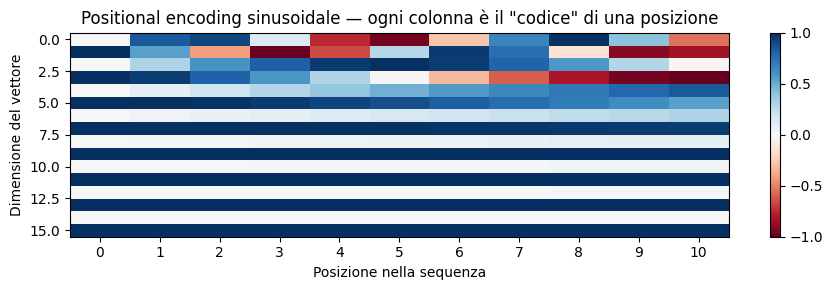

In [9]:
def make_positional_encoding(context_len, d_model):
    pe = torch.zeros(context_len, d_model)
    position = torch.arange(context_len).unsqueeze(1).float()
    div_term = torch.exp(
        torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
    )
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe

pe = make_positional_encoding(context_len, d_model)
print(f"Positional encoding: {pe.shape}  ({context_len} posizioni × {d_model} dimensioni)")

fig, ax = plt.subplots(figsize=(9, 3))
im = ax.imshow(pe.numpy().T, aspect='auto', cmap='RdBu', vmin=-1, vmax=1)
ax.set_xlabel('Posizione nella sequenza')
ax.set_ylabel('Dimensione del vettore')
ax.set_title('Positional encoding sinusoidale — ogni colonna è il "codice" di una posizione')
ax.set_xticks(range(context_len))
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [10]:
# 'cipolla' appears at position 2 in sentence 1 and at position 3 in sentence 141
sent_pos2 = sentences[1]    # 'tagliate la cipolla .'
sent_pos3 = sentences[141]  # 'lasciate cuocere la cipolla finché è morbida .'

cipolla_idx = tokenizer.word2idx['cipolla']
tok_vec = token_emb(torch.tensor(cipolla_idx)).detach()

final_pos2 = tok_vec + pe[2]
final_pos3 = tok_vec + pe[3]

cos_sim = torch.nn.functional.cosine_similarity(
    final_pos2.unsqueeze(0), final_pos3.unsqueeze(0)
).item()

print("Frasi di confronto:")
print(f"  A (pos 2): '{sent_pos2}'")
print(f"  B (pos 3): '{sent_pos3}'")
print()
print(f"Token embedding di 'cipolla' (identico in entrambi i casi):")
print(f"  {tok_vec.numpy().round(3)}")
print()
print(f"Dopo aver sommato il positional encoding:")
print(f"  pos 2 → {final_pos2.detach().numpy().round(3)}")
print(f"  pos 3 → {final_pos3.detach().numpy().round(3)}")
print()
print(f"Cosine similarity tra le due rappresentazioni finali: {cos_sim:.4f}")
print("(1.0 = identiche  |  0.0 = ortogonali  |  -1.0 = opposte)")

Frasi di confronto:
  A (pos 2): 'tagliate la cipolla .'
  B (pos 3): 'lasciate cuocere la cipolla finché è morbida .'

Token embedding di 'cipolla' (identico in entrambi i casi):
  [ 0.025 -1.064 -0.76  -0.408  0.962 -0.143  0.153 -0.039  0.945 -1.582
  0.987  1.146 -0.142 -0.276 -0.193  0.777]

Dopo aver sommato il positional encoding:
  pos 2 → [ 0.934 -1.48  -0.169  0.399  1.161  0.837  0.216  0.959  0.965 -0.583
  0.993  2.146 -0.14   0.724 -0.193  1.777]
  pos 3 → [ 0.166 -2.054  0.052  0.175  1.258  0.813  0.247  0.957  0.975 -0.583
  0.997  2.146 -0.139  0.724 -0.192  1.777]

Cosine similarity tra le due rappresentazioni finali: 0.9712
(1.0 = identiche  |  0.0 = ortogonali  |  -1.0 = opposte)


## 4. Self-attention

### Il problema: i vettori non si "parlano"

Dopo embedding e positional encoding, ogni posizione della sequenza ha la propria
rappresentazione — ma è ancora cieca rispetto al contesto. Il vettore di `cipolla`
alla posizione 2 non sa che alla posizione 0 c'è `tagliate`: non riesce a costruire
il significato "cipolla-oggetto-di-un-taglio".

Il transformer risolve questo con la **self-attention**: ogni token costruisce una nuova
rappresentazione raccogliendo informazioni dagli altri token della sequenza, pesate per
rilevanza. Lo stesso token `cipolla` avrà rappresentazioni diverse in "tagliate la
cipolla" rispetto a "cuocete la cipolla", perché il contesto è diverso.

---

### Un lookup differenziabile

La domanda operativa è: *per il token `i`, quanto è rilevante ogni altro token `j`?*

L'approccio più semplice — confrontare direttamente i vettori di input — non funziona
bene: ogni vettore deve fare troppe cose contemporaneamente (codificare il significato
del token, servire da criterio di ricerca, contenere il valore da trasmettere).

La soluzione è separare queste tre funzioni con tre proiezioni lineari distinte:

| Proiezione | Nome | Ruolo |
|---|---|---|
| `x · W_Q` | **Query** | *Cosa sto cercando?* La "domanda" che il token pone agli altri |
| `x · W_K` | **Key** | *Cosa contengo?* L'"etichetta" con cui un token si rende cercabile |
| `x · W_V` | **Value** | *Cosa trasmetto se vengo selezionato?* L'informazione che passa |

`W_Q`, `W_K`, `W_V` ∈ ℝ^(d_model × d_k) sono matrici apprese. Ogni token `i` proietta
il proprio vettore di input in tutti e tre gli spazi:

```
Q_i = x_i · W_Q,    K_i = x_i · W_K,    V_i = x_i · W_V
```

---

### Misurare la rilevanza: prodotto scalare

La rilevanza del token `j` rispetto al token `i` si misura con il **prodotto scalare**
tra la query di `i` e la key di `j`:

```
score(i, j) = Q_i · K_j
```

Un prodotto scalare alto significa che i due vettori sono allineati — il token `j`
"risponde alla domanda" posta da `i`. In forma matriciale calcoliamo tutti i punteggi
in una sola operazione:

```
Scores = Q · Kᵀ          shape: (T × T)
```

Ogni riga `i` contiene i punteggi di tutti i token `j` rispetto al token `i`.

---

### Scaling: perché dividere per √d_k

Con dimensioni alte (tipicamente d_k = 64), i prodotti scalari crescono in modulo:
vettori casuali di dimensione d hanno varianza d, quindi il prodotto scalare ha
deviazione standard √d_k. Valori molto grandi entrano nella zona di saturazione del
softmax, dove i gradienti sono quasi zero e l'apprendimento si blocca.

La soluzione è dividere per √d_k prima del softmax:

```
Scores = Q · Kᵀ / √d_k
```

---

### Softmax: da punteggi a pesi

Applicando il softmax riga per riga si ottiene una distribuzione di probabilità: i pesi
sommano a 1 e i token più rilevanti ricevono peso maggiore.

```
A = softmax( Q · Kᵀ / √d_k )          shape: (T × T)
```

`A[i, j]` si legge: "quanto il token `i` si concentra sul token `j`."

---

### Output: somma pesata dei valori

L'output per ogni token `i` è la somma pesata dei vettori Value di tutti i token:

```
Output = A · V                          shape: (T × d_k)
```

La rappresentazione aggiornata di `i` è una miscela dei valori di tutti gli altri token,
pesata dalla loro rilevanza. La formula completa, messa insieme, è:

```
Attention(Q, K, V) = softmax( Q · Kᵀ / √d_k ) · V
```

---

### La causal mask: vietare lo sguardo al futuro

Nel nostro modello autoregressivo, la predizione alla posizione `t` non deve dipendere
dai token in `t+1, t+2, ...` (al momento dell'inferenza non esistono ancora). Prima
del softmax, sostituiamo con −∞ i punteggi che corrispondono a posizioni future:
il softmax di −∞ è 0, quindi quei token non contribuiranno mai all'output.

```
        j=0   j=1   j=2   j=3   j=4
i=0  [  ok    −∞    −∞    −∞    −∞  ]
i=1  [  ok    ok    −∞    −∞    −∞  ]
i=2  [  ok    ok    ok    −∞    −∞  ]
i=3  [  ok    ok    ok    ok    −∞  ]
i=4  [  ok    ok    ok    ok    ok  ]
```

Questo è esattamente ciò che permette di addestrare con sequenze intere ma inferire
token per token: la struttura triangolare rispecchia il processo autoregressivo.

---

### Multi-head attention

Un singolo meccanismo di attention può catturare un solo tipo di relazione alla volta.
La soluzione è eseguire `h` attention in parallelo, ciascuna con proiezioni proprie di
dimensione ridotta d_k = d_model / h:

```
head_r = Attention(x · W_Q^r,  x · W_K^r,  x · W_V^r)

MultiHead(x) = concat(head_1, ..., head_h) · W_O
```

La concatenazione riporta la dimensione a d_model; `W_O` ∈ ℝ^(d_model × d_model) mescola
le informazioni raccolte dai diversi head. I head possono specializzarsi su relazioni
diverse: uno potrebbe imparare a collegare un verbo ai suoi argomenti, un altro a
tracciare dipendenze sintattiche, un altro a raggruppare token semanticamente affini.

### Demo: ogni passaggio su una frase concreta

Costruiamo Q, K e V a mano per la frase `tagliate la cipolla poi cuocete lentamente .`,
con valori inventati ma motivati dalla struttura della frase. L'obiettivo non è riprodurre
pesi linguisticamente corretti — il modello non è ancora addestrato — ma rendere ogni
operazione numericamente osservabile.

Usiamo una sola head e d_k = 4. Le matrici sono costruite così:
- **dimensioni 0–1**: catturano relazioni nel primo sintagma (verbo / articolo / nome)
- **dimensioni 2–3**: catturano relazioni nel secondo sintagma (connettivo / verbo2)

In un modello reale Q = X · W_Q e K = X · W_K, dove W_Q e W_K sono matrici
apprese durante il training. Qui definiamo Q e K direttamente per leggibilità.

In [11]:
import torch.nn.functional as F

sentence = sentences[86]   # 'tagliate la cipolla poi cuocete lentamente .'
tokens = sentence.split()
T, d_k = len(tokens), 4

# Q: what each token is looking for
Q = torch.tensor([
    [2.0, 0.0, 0.0, 0.0],  # tagliate: solo se stesso
    [1.5, 0.5, 0.0, 0.0],  # la: cerca il verbo (dim 0)
    [1.0, 1.5, 0.0, 0.0],  # cipolla: cerca articolo e verbo
    [0.0, 0.0, 2.0, 0.0],  # poi: cerca se stesso (connettivo)
    [0.0, 0.0, 2.0, 0.5],  # cuocete: cerca il connettivo
    [0.0, 0.0, 1.0, 2.0],  # lentamente: cerca il verbo della sua clause
    [0.0, 0.0, 0.5, 1.0],  # .: segnale di fine
])

# K: what each token offers
K = torch.tensor([
    [1.5, 0.5, 0.0, 0.0],  # tagliate: si offre come verbo
    [0.5, 1.0, 0.0, 0.0],  # la: si offre come articolo
    [0.3, 1.5, 0.0, 0.0],  # cipolla: si offre come nome
    [0.0, 0.0, 1.5, 0.5],  # poi: si offre come connettivo
    [0.0, 0.0, 0.5, 1.5],  # cuocete: si offre come verbo2
    [0.0, 0.0, 0.0, 1.5],  # lentamente: si offre come avverbio
    [0.0, 0.0, 0.0, 0.5],  # .: punteggiatura
])

# V: the information each token transmits if selected
# each token has a distinctive unit direction so the output is readable
V = torch.tensor([
    [1.0, 0.0, 0.0, 0.0],  # tagliate
    [0.0, 1.0, 0.0, 0.0],  # la
    [0.0, 0.0, 1.0, 0.0],  # cipolla
    [0.0, 0.0, 0.0, 1.0],  # poi
    [0.7, 0.7, 0.0, 0.0],  # cuocete  (simile a tagliate: altro verbo)
    [0.0, 0.0, 0.7, 0.7],  # lentamente
    [0.5, 0.5, 0.5, 0.5],  # .
])

print(f"Frase : '{sentence}'")
print(f"Token : {tokens}")
print(f"\nQ {tuple(Q.shape)},  K {tuple(K.shape)},  V {tuple(V.shape)}")

Frase : 'tagliate la cipolla poi cuocete lentamente .'
Token : ['tagliate', 'la', 'cipolla', 'poi', 'cuocete', 'lentamente', '.']

Q (7, 4),  K (7, 4),  V (7, 4)


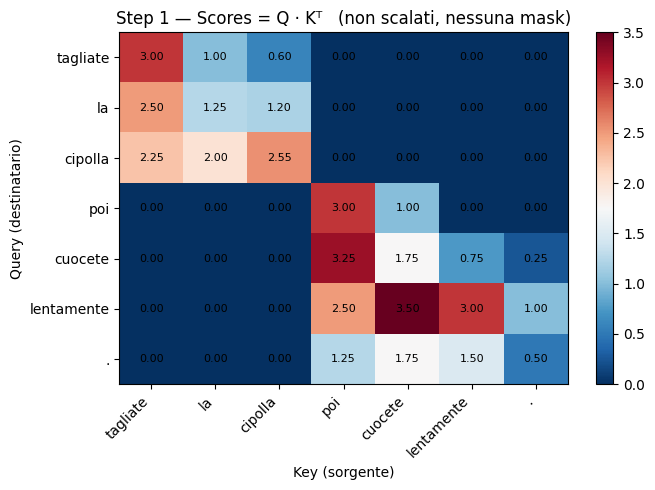

Shape: torch.Size([7, 7])


In [12]:
# Step 1 — raw scores: Q · Kᵀ
scores_raw = Q @ K.T   # (T, T)

def annotated_heatmap(ax, data, row_labels, col_labels, title, cmap='RdBu_r',
                      vmin=None, vmax=None, fmt='{:.2f}', nan_label=''):
    display = data.copy()
    im = ax.imshow(display, cmap=cmap, aspect='auto', vmin=vmin, vmax=vmax)
    for i in range(len(row_labels)):
        for j in range(len(col_labels)):
            v = data[i, j]
            label = nan_label if (v != v) else fmt.format(v)  # nan check
            ax.text(j, i, label, ha='center', va='center', fontsize=8,
                    color='gray' if label == nan_label else 'black')
    ax.set_xticks(range(len(col_labels))); ax.set_xticklabels(col_labels, rotation=45, ha='right')
    ax.set_yticks(range(len(row_labels))); ax.set_yticklabels(row_labels)
    ax.set_title(title)
    return im

fig, ax = plt.subplots(figsize=(7, 5))
im = annotated_heatmap(ax, scores_raw.numpy(), tokens, tokens,
                       'Step 1 — Scores = Q · Kᵀ   (non scalati, nessuna mask)')
ax.set_xlabel('Key (sorgente)'); ax.set_ylabel('Query (destinatario)')
plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()
print(f"Shape: {scores_raw.shape}")

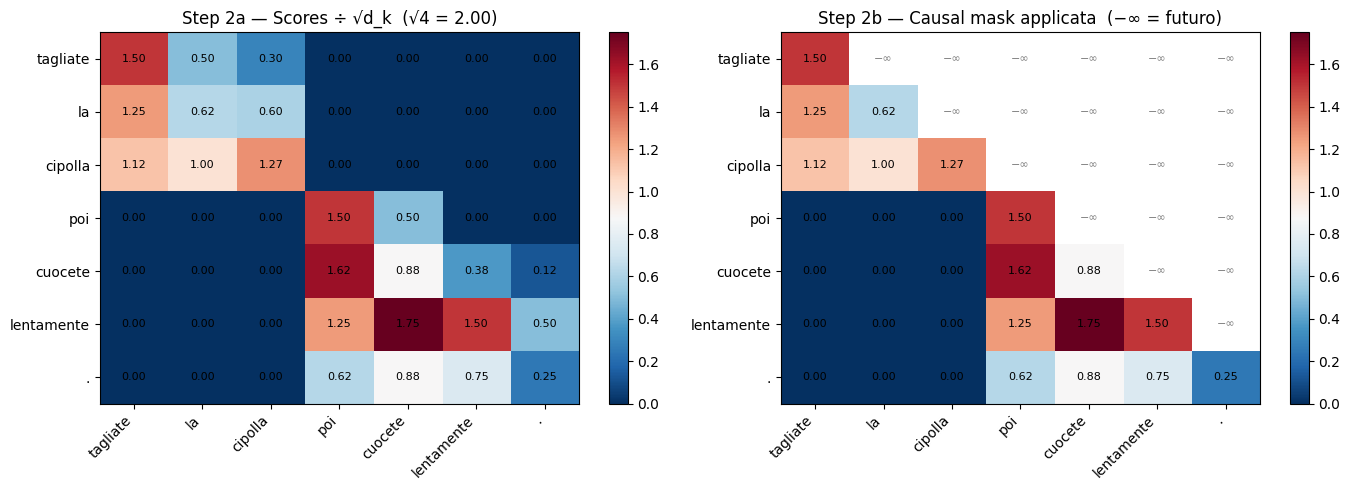

In [13]:
# Step 2 — scaling + causal mask
scores_scaled = scores_raw / math.sqrt(d_k)

causal_mask = torch.triu(torch.ones(T, T), diagonal=1).bool()
scores_masked = scores_scaled.masked_fill(causal_mask, float('-inf'))

# Replace -inf with NaN only for display (imshow can't handle -inf)
def to_display(t):
    a = t.numpy().copy().astype(float)
    a[a == float('-inf')] = float('nan')
    return a

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = annotated_heatmap(axes[0], scores_scaled.numpy(), tokens, tokens,
                        f'Step 2a — Scores ÷ √d_k  (√{d_k} = {math.sqrt(d_k):.2f})')
plt.colorbar(im0, ax=axes[0])

im1 = annotated_heatmap(axes[1], to_display(scores_masked), tokens, tokens,
                        'Step 2b — Causal mask applicata  (−∞ = futuro)', nan_label='−∞')
plt.colorbar(im1, ax=axes[1])

plt.tight_layout(); plt.show()

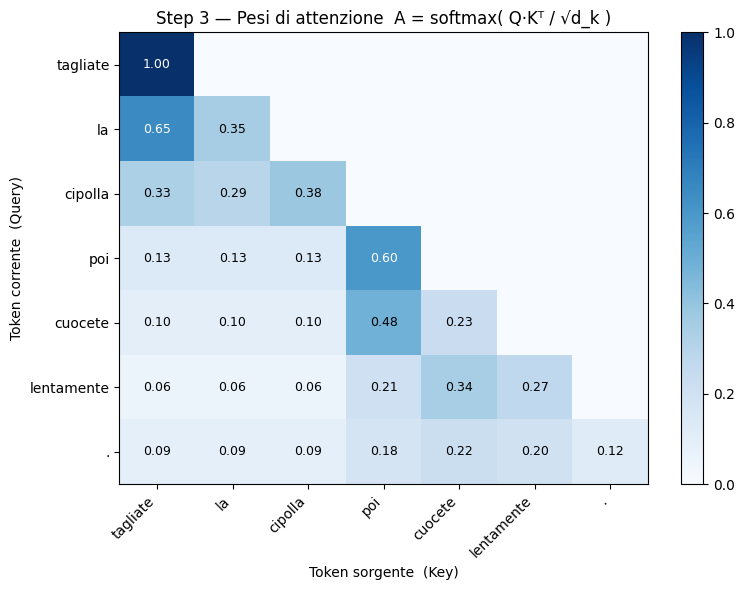

Verifica: ogni riga somma a 1
[1. 1. 1. 1. 1. 1. 1.]


In [14]:
# Step 3 — softmax → attention weights
A = F.softmax(scores_masked, dim=-1)   # each row sums to 1

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(A.numpy(), cmap='Blues', vmin=0, vmax=1, aspect='auto')
for i in range(T):
    for j in range(T):
        val = A[i, j].item()
        if val > 0.005:
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=9,
                    color='white' if val > 0.55 else 'black')
ax.set_xticks(range(T)); ax.set_xticklabels(tokens, rotation=45, ha='right')
ax.set_yticks(range(T)); ax.set_yticklabels(tokens)
ax.set_xlabel('Token sorgente  (Key)'); ax.set_ylabel('Token corrente  (Query)')
ax.set_title('Step 3 — Pesi di attenzione  A = softmax( Q·Kᵀ / √d_k )')
plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

print("Verifica: ogni riga somma a 1")
print(A.sum(dim=-1).detach().numpy().round(6))

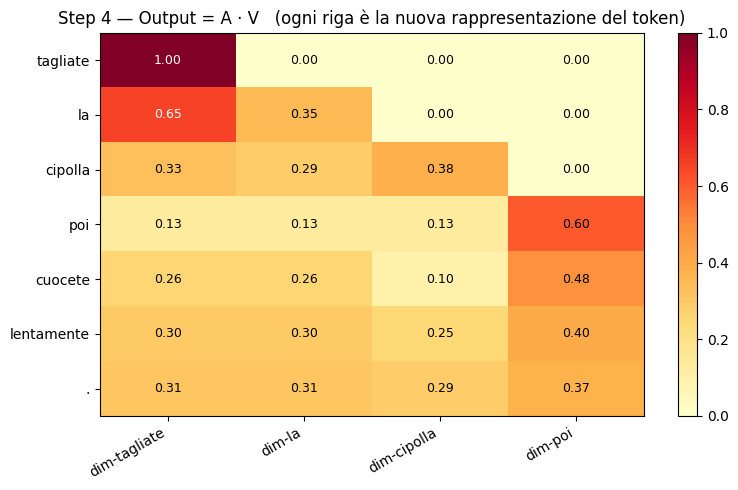


Lettura dell'output:
      tagliate: solo se stesso → vettore puro di 'tagliate'
            la: guarda tagliate(65%) → rappresentazione mista verbo+articolo
       cipolla: guarda tutto il sintagma → mix di verbo, articolo, nome
           poi: si guarda (60%) → dominato da 'poi'
       cuocete: guarda poi(48%) → assorbisce l'informazione del connettivo
    lentamente: guarda cuocete(34%) → trascina con sé anche il segnale di 'poi'
             .: . →  mix diffuso su tutta la seconda clause


In [15]:
# Step 4 — output: weighted sum of Values
output = A @ V   # (T, d_k)

# V column labels: the "name" of each dimension is the token whose V vector lives there
v_dims = ['dim-tagliate', 'dim-la', 'dim-cipolla', 'dim-poi']

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(output.detach().numpy(), cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')
for i in range(T):
    for j in range(d_k):
        val = output[i, j].item()
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=9,
                color='white' if val > 0.6 else 'black')
ax.set_xticks(range(d_k)); ax.set_xticklabels(v_dims, rotation=30, ha='right')
ax.set_yticks(range(T)); ax.set_yticklabels(tokens)
ax.set_title('Step 4 — Output = A · V   (ogni riga è la nuova rappresentazione del token)')
plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

print("\nLettura dell'output:")
notes = [
    "solo se stesso → vettore puro di 'tagliate'",
    "guarda tagliate(65%) → rappresentazione mista verbo+articolo",
    "guarda tutto il sintagma → mix di verbo, articolo, nome",
    "si guarda (60%) → dominato da 'poi'",
    "guarda poi(48%) → assorbisce l'informazione del connettivo",
    "guarda cuocete(34%) → trascina con sé anche il segnale di 'poi'",
    ". →  mix diffuso su tutta la seconda clause",
]
for tok, note in zip(tokens, notes):
    print(f"  {tok:>12}: {note}")

## 5. Feed-forward layer

### Perché esiste, se abbiamo già l'attention?

Il meccanismo di attention è potente per aggregare informazioni **tra posizioni diverse**,
ma ha un limite strutturale: l'output è una somma pesata dei vettori Value.
Sommre pesate sono operazioni **lineari** — concatenarne tante non aggiunge espressività,
perché la composizione di funzioni lineari è ancora lineare.

Il feed-forward layer (FFN) introduce **non-linearità** e aumenta la capacità
espressiva del modello. La sua formula è semplice:

```
FFN(x) = ReLU( x · W₁ + b₁ ) · W₂ + b₂
```

Due proiezioni lineari con una ReLU in mezzo. La prima espande la dimensione
(tipicamente a 4 × d_model), la seconda la riporta a d_model.

```
         d_model          d_ff = 4·d_model       d_model
    x ──── W₁ ──── ReLU ──────── W₂ ────── output
    (T × d_model)      (T × d_ff)         (T × d_model)
```

### Cosa fa esattamente?

L'FFN è applicato **posizione per posizione**: ogni token viene trasformato
indipendentemente dagli altri. Non mescola informazioni tra token — quello è il
compito dell'attention.

Si può pensare ai due sublayer come a due operazioni complementari:

- **Attention**: *routing* — decide quali token guardare e quanto pesarli
- **FFN**: *computation* — applica una trasformazione non-lineare all'informazione raccolta

Una lettura alternativa dalla mechanistic interpretability: l'FFN funziona come
una **memoria associativa**. Nei modelli grandi, la maggior parte dei "fatti" appresi
(associazioni tra concetti) è codificata nei pesi W₁ e W₂, non nella matrice di attention.

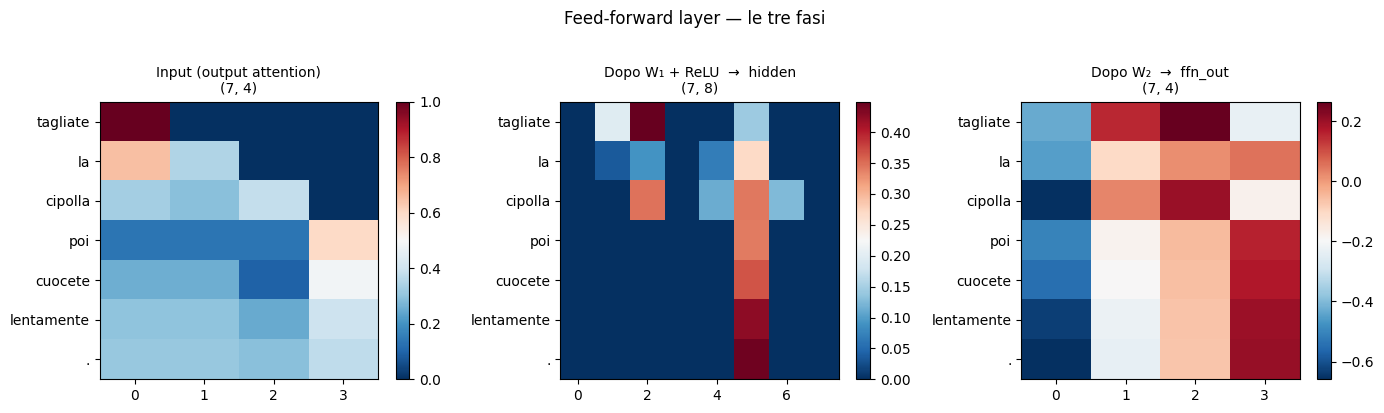

Attivazioni azzerate da ReLU per token:
      tagliate: ███░░░░░  (3/8 attive)
            la: ████░░░░  (4/8 attive)
       cipolla: ████░░░░  (4/8 attive)
           poi: █░░░░░░░  (1/8 attive)
       cuocete: █░░░░░░░  (1/8 attive)
    lentamente: █░░░░░░░  (1/8 attive)
             .: █░░░░░░░  (1/8 attive)


In [16]:
# Demo FFN sull'output dell'attention calcolato sopra
# Nel demo: d_in = d_k = 4, d_ff = 8  (2×, più piccolo del solito per leggibilità)
d_in, d_ff = d_k, 8
torch.manual_seed(7)

W1 = torch.randn(d_in, d_ff) * 0.5
b1 = torch.zeros(d_ff)
W2 = torch.randn(d_ff, d_in) * 0.5
b2 = torch.zeros(d_in)

# Step by step
hidden = output @ W1 + b1          # (T, d_ff)  — proiezione espansiva
hidden_relu = hidden.clamp(min=0)   # ReLU
ffn_out = hidden_relu @ W2 + b2     # (T, d_in)  — proiezione contrattiva

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
titles = [
    f'Input (output attention)\n{tuple(output.shape)}',
    f'Dopo W₁ + ReLU  →  hidden\n{tuple(hidden_relu.shape)}',
    f'Dopo W₂  →  ffn_out\n{tuple(ffn_out.shape)}',
]
for ax, data, title in zip(axes,
        [output.detach(), hidden_relu.detach(), ffn_out.detach()], titles):
    im = ax.imshow(data.numpy(), cmap='RdBu_r', aspect='auto')
    ax.set_yticks(range(T)); ax.set_yticklabels(tokens)
    ax.set_title(title, fontsize=10)
    plt.colorbar(im, ax=ax)

plt.suptitle('Feed-forward layer — le tre fasi', y=1.02)
plt.tight_layout(); plt.show()

# Quante attivazioni ReLU sono zero per ogni token?
zeros_per_token = (hidden_relu == 0).sum(dim=-1)
print("Attivazioni azzerate da ReLU per token:")
for tok, n in zip(tokens, zeros_per_token.tolist()):
    bar = '█' * (d_ff - n) + '░' * n
    print(f"  {tok:>12}: {bar}  ({d_ff - n}/{d_ff} attive)")

## 6. Transformer Block e residual stream

### Mettere insieme attention e FFN

Un **transformer block** combina i due sublayer in sequenza, con due aggiunte
che rendono il training stabile e profondo: le **connessioni residue** e la
**layer normalization**.

La struttura di un blocco completo (nella variante *pre-norm*, quella moderna) è:

```
x  ──────────────────────────────────────────────────────────  x
│                                                              │
│   ┌──────────────────────────────────────────────────────┐  │
│   │                                                      │  │
└──▶│  LayerNorm  →  CausalAttention  →  +  ──────────────▶│──┘
    │                                   ↑                  │
    │                                   │ (residual)       │
    │                                   └── x              │
    │                                                      │
    │  LayerNorm  →  FeedForward  →  +  ──────────────────▶│
    │                                ↑                     │
    │                                └── x (residual)      │
    └──────────────────────────────────────────────────────┘
```

In forma compatta:

```python
x = x + Attention( LayerNorm(x) )
x = x + FFN( LayerNorm(x) )
```

### Il residual stream

Le connessioni residue non sono solo un trucco di ottimizzazione: cambiano
**come si deve pensare al flusso dell'informazione**.

Senza residual, ogni layer trasforma completamente la rappresentazione.
Con il residual, ogni layer **aggiunge un delta** a un flusso che scorre
inalterato dall'embedding fino all'output:

```
embedding  →  +Δ₁_attn  →  +Δ₁_ffn  →  +Δ₂_attn  →  +Δ₂_ffn  →  ...  →  logit
              ──────────── block 1 ──────────────────── block 2 ──────
```

Questa prospettiva — il *residual stream* — è utile per capire cosa fa ogni
componente: ogni sublayer legge dal flusso, scrive un contributo, e il flusso
continua arricchito. I layer profondi possono ignorare il proprio input
(scrivendo Δ ≈ 0) se non hanno nulla da aggiungere.

Il vantaggio durante il training è che il gradiente può tornare indietro
attraverso le connessioni additive senza attenursi: anche con molti layer,
c'è sempre un percorso diretto dal loss fino all'embedding.

### Layer normalization

La layer norm normalizza ogni vettore (lungo la dimensione d_model)
a media zero e varianza unitaria, poi reintroduce due parametri appresi
γ (scale) e β (shift):

```
LayerNorm(x) = γ · (x − μ) / (σ + ε) + β
```

Applicata **prima** del sublayer (pre-norm), stabilizza i valori in ingresso
all'attention e all'FFN, rendendo il training più robusto agli iperparametri.

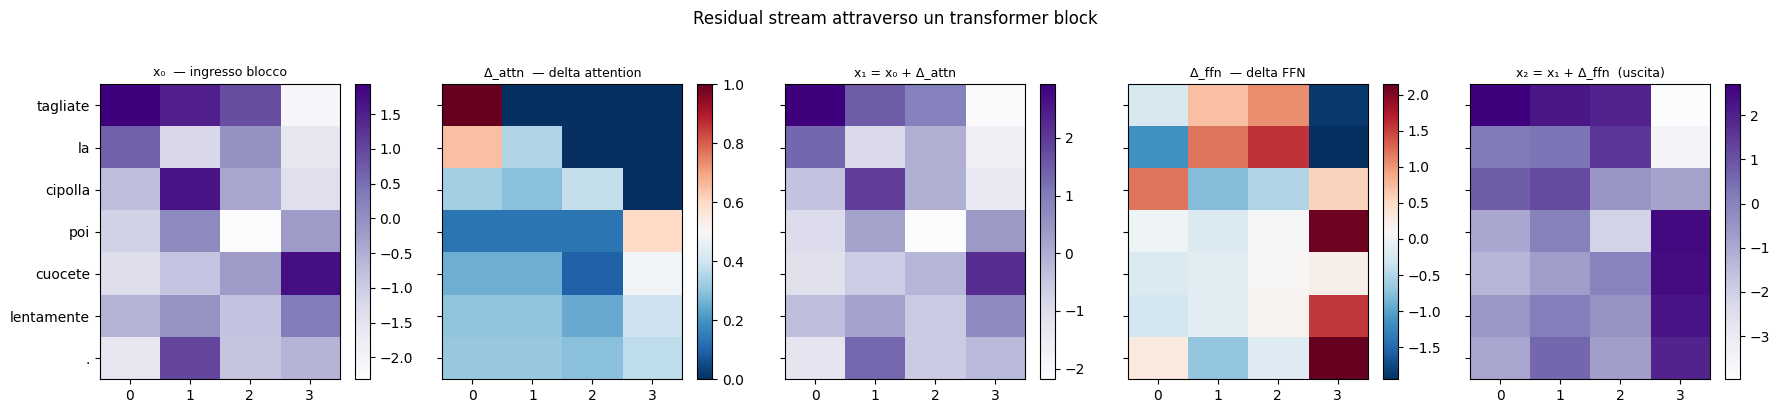

Norma media Δ_attn : 0.6934
Norma media Δ_ffn  : 1.8842
Norma media x₀     : 2.2817

Ogni sublayer modifica il flusso di circa 30.4% (attn) e 79.5% (FFN) della norma dell'input.


In [17]:
# Transformer Block — mostriamo il residual stream passo per passo
# Usiamo come punto di partenza un vettore x fittizio di dim d_in=4 per ogni token
torch.manual_seed(42)
x = torch.randn(T, d_in)   # simula l'output di embedding + positional enc

layer_norm = torch.nn.LayerNorm(d_in)

def causal_attention(x):
    """Single-head attention with our crafted Q, K, V (reuses matrices from above)."""
    q = x @ Q[:d_in, :]   # proiezione semplificata: usa le prime d_in righe di Q come W_Q
    q = Q                  # override: usa direttamente i Q inventati per coerenza con il demo
    k = K
    v = V
    s = q @ k.T / math.sqrt(d_k)
    mask = torch.triu(torch.ones(T, T), diagonal=1).bool()
    s = s.masked_fill(mask, float('-inf'))
    a = F.softmax(s, dim=-1)
    return a @ v

def feed_forward(x):
    h = (x @ W1 + b1).clamp(min=0)
    return h @ W2 + b2

# --- residual stream: tre istantanee ---
x0 = x.clone()                           # ingresso del blocco
x1 = x0 + causal_attention(layer_norm(x0))   # dopo attention + residual
x2 = x1 + feed_forward(layer_norm(x1))       # dopo FFN + residual

delta_attn = x1 - x0    # contributo dell'attention al flusso
delta_ffn  = x2 - x1    # contributo dell'FFN al flusso

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
panels = [
    (x0.detach(),         'x₀  — ingresso blocco',     'Purples'),
    (delta_attn.detach(), 'Δ_attn  — delta attention',  'RdBu_r'),
    (x1.detach(),         'x₁ = x₀ + Δ_attn',          'Purples'),
    (delta_ffn.detach(),  'Δ_ffn  — delta FFN',         'RdBu_r'),
    (x2.detach(),         'x₂ = x₁ + Δ_ffn  (uscita)',  'Purples'),
]
for ax, (data, title, cmap) in zip(axes, panels):
    im = ax.imshow(data.numpy(), cmap=cmap, aspect='auto')
    ax.set_yticks(range(T)); ax.set_yticklabels(tokens if ax is axes[0] else [])
    ax.set_title(title, fontsize=9)
    plt.colorbar(im, ax=ax)

plt.suptitle('Residual stream attraverso un transformer block', y=1.02)
plt.tight_layout(); plt.show()

# Norma dei delta: quanto "scrive" ciascun sublayer?
print(f"Norma media Δ_attn : {delta_attn.norm(dim=-1).mean():.4f}")
print(f"Norma media Δ_ffn  : {delta_ffn.norm(dim=-1).mean():.4f}")
print(f"Norma media x₀     : {x0.norm(dim=-1).mean():.4f}")
print(f"\nOgni sublayer modifica il flusso di circa "
      f"{delta_attn.norm(dim=-1).mean() / x0.norm(dim=-1).mean() * 100:.1f}% "
      f"(attn) e "
      f"{delta_ffn.norm(dim=-1).mean() / x1.norm(dim=-1).mean() * 100:.1f}% "
      f"(FFN) della norma dell'input.")

## 7. Proiezione finale: da vettore a distribuzione sul vocabolario

### A cosa serve

Dopo l'ultimo transformer block, ogni posizione `t` della sequenza ha una
rappresentazione densa di dimensione `d_model`. Questa rappresentazione contiene
informazioni contestualizzate sul token in posizione `t` — ma non è ancora una
predizione: è un vettore in uno spazio interno al modello, non confrontabile con
i token del vocabolario.

Per ottenere una predizione dobbiamo rispondere alla domanda: *dato tutto quello
che il modello ha visto fino alla posizione `t`, qual è la distribuzione di
probabilità sul token successivo?*

La risposta è una proiezione lineare:

```
logits = x · W_out          W_out ∈ ℝ^(d_model × vocab_size)
probs  = softmax(logits)
```

Per ogni posizione otteniamo un vettore di `vocab_size` valori reali (*logits*),
che il softmax converte in una distribuzione di probabilità. Il token con
probabilità massima è la predizione del modello per quella posizione.

### Weight tying

In molti modelli (GPT-2 incluso) `W_out` è semplicemente la trasposta della
matrice di embedding dei token `W_emb`. L'intuizione: se due token sono vicini
nello spazio degli embedding (hanno vettori simili), il modello li considera
intercambiabili anche come predizioni. Questo dimezza i parametri della
proiezione finale senza perdita di qualità.

### Cosa ci aspettiamo senza training

Con pesi casuali la distribuzione prodotta dal softmax è **quasi uniforme**:
ogni token del vocabolario ha circa probabilità 1/vocab_size ≈ 1.8%.
Il training sposterà massa di probabilità verso i token corretti, rendendo
la distribuzione sempre più peaked intorno alla risposta giusta.

### Connessione con il training

Ricordando la struttura del dataset: l'input alla posizione `t` è il token
`t`, il target è il token `t+1`. La loss è la cross-entropy tra la
distribuzione predetta alla posizione `t` e il token target `t+1` —
esattamente il valore `y[t]` costruito durante il dataset preparation.

In [18]:
vocab_size = tokenizer.vocab_size
torch.manual_seed(3)
W_out = torch.randn(d_in, vocab_size) * 0.1   # piccola inizializzazione

logits = x2 @ W_out                           # (T, vocab_size)
probs  = F.softmax(logits, dim=-1)            # (T, vocab_size)

print(f"x2 (output blocco) : {tuple(x2.shape)}")
print(f"W_out              : ({d_in}, {vocab_size})")
print(f"logits             : {tuple(logits.shape)}")
print(f"probs              : {tuple(probs.shape)}")
print(f"\nProb. uniforme di riferimento : {1/vocab_size:.4f}  ({1/vocab_size*100:.2f}%)")
print(f"Range prob. effettivo         : [{probs.min():.4f}, {probs.max():.4f}]")

x2 (output blocco) : (7, 4)
W_out              : (4, 57)
logits             : (7, 57)
probs              : (7, 57)

Prob. uniforme di riferimento : 0.0175  (1.75%)
Range prob. effettivo         : [0.0058, 0.0542]


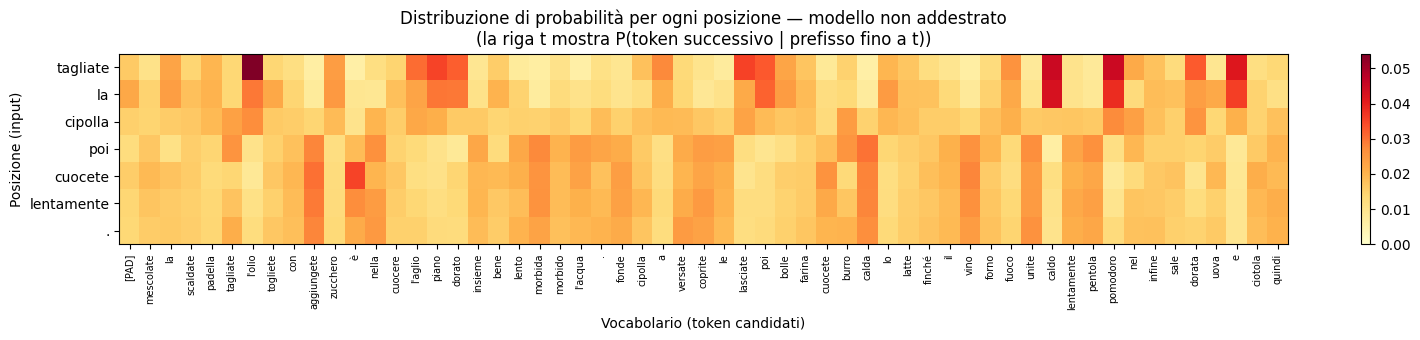

In [19]:
# Heatmap della distribuzione di probabilità: T posizioni × vocab_size token
fig, ax = plt.subplots(figsize=(16, 3.5))
im = ax.imshow(probs.detach().numpy(), cmap='YlOrRd', aspect='auto',
               vmin=0, vmax=probs.max().item())
ax.set_yticks(range(T))
ax.set_yticklabels(tokens)
ax.set_xticks(range(vocab_size))
ax.set_xticklabels(tokenizer.vocab, rotation=90, fontsize=7)
ax.set_xlabel('Vocabolario (token candidati)')
ax.set_ylabel('Posizione (input)')
ax.set_title('Distribuzione di probabilità per ogni posizione — modello non addestrato\n'
             '(la riga t mostra P(token successivo | prefisso fino a t))')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [20]:
# Top-5 predizioni per ogni posizione, con il token target corretto
targets = sentence.split()[1:] + ['—']   # token t+1 per ogni posizione t

print(f"Frase: '{sentence}'\n")
print(f"{'pos':>3}  {'input':>12}  {'target corretto':>16}  {'top-5 predizioni (prob%)':}")
print('─' * 78)
for t in range(T):
    top5_idx  = probs[t].topk(5).indices.tolist()
    top5_prob = probs[t].topk(5).values.tolist()
    top5_str  = '  '.join(f"{tokenizer.idx2word[i]}({p*100:.1f}%)"
                          for i, p in zip(top5_idx, top5_prob))
    target = targets[t]
    hit = '✓' if target in [tokenizer.idx2word[i] for i in top5_idx] else ' '
    print(f"{t:>3}  {tokens[t]:>12}  {target:>16}  {hit} {top5_str}")

Frase: 'tagliate la cipolla poi cuocete lentamente .'

pos         input   target corretto  top-5 predizioni (prob%)
──────────────────────────────────────────────────────────────────────────────
  0      tagliate                la    l'olio(5.4%)  caldo(4.5%)  pomodoro(4.5%)  e(4.1%)  lasciate(3.5%)
  1            la           cipolla    caldo(4.3%)  pomodoro(3.8%)  e(3.6%)  poi(3.2%)  piano(3.0%)
  2       cipolla               poi    pomodoro(2.7%)  l'olio(2.7%)  dorata(2.6%)  burro(2.4%)  nel(2.4%)
  3           poi           cuocete    calda(3.0%)  aggiungete(2.8%)  morbida(2.7%)  unite(2.7%)  nella(2.6%)
  4       cuocete        lentamente    è(3.5%)  aggiungete(3.0%)  calda(2.8%)  vino(2.8%)  cuocete(2.6%)
  5    lentamente                 .    aggiungete(2.9%)  calda(2.8%)  è(2.7%)  vino(2.6%)  morbida(2.6%)
  6             .                 —    aggiungete(2.8%)  calda(2.7%)  unite(2.6%)  nella(2.5%)  versate(2.4%)


## 8. Modello completo: training e inferenza

Abbiamo visto ogni componente in isolamento. In questa sezione li assembliamo in un
unico modello PyTorch, lo addestriamo sul corpus di ricette e lo usiamo per generare
testo e produrre rappresentazioni vettoriali delle frasi.

### Architettura

| Iperparametro | Valore | Note |
|---|---|---|
| `d_model` | 64 | dimensione del residual stream |
| `n_heads` | 4 | → `d_k = 16` per head |
| `d_ff` | 128 | dimensione interna FFN (2× d_model) |
| `n_layers` | 2 | numero di transformer block |
| `context_len` | 11 | lunghezza massima della sequenza |
| `vocab_size` | 57 | token del corpus + `[PAD]` |

La proiezione finale usa **weight tying**: `W_out = W_emb.T`, così il modello usa
la stessa matrice per mappare token → vettore e per mappare vettore → token.

In [21]:
import torch.nn as nn

class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, context_len):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.W_qkv = nn.Linear(d_model, 3 * d_model, bias=False)
        self.W_out = nn.Linear(d_model, d_model, bias=False)
        self.register_buffer('mask',
            torch.triu(torch.ones(context_len, context_len), diagonal=1).bool())

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.W_qkv(x).split(C, dim=-1)
        # reshape to (B, n_heads, T, d_k)
        q = q.view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.d_k)
        scores = scores.masked_fill(self.mask[:T, :T], float('-inf'))
        a = F.softmax(scores, dim=-1)
        out = (a @ v).transpose(1, 2).contiguous().view(B, T, C)
        return self.W_out(out)


class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model),
        )

    def forward(self, x):
        return self.net(x)


class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, context_len):
        super().__init__()
        self.ln1  = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads, context_len)
        self.ln2  = nn.LayerNorm(d_model)
        self.ffn  = FeedForward(d_model, d_ff)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))   # residual + attention
        x = x + self.ffn(self.ln2(x))    # residual + FFN
        return x


class MiniTransformer(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, d_ff, n_layers, context_len):
        super().__init__()
        self.context_len = context_len
        self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=Tokenizer.PAD_IDX)
        self.register_buffer('pe', make_positional_encoding(context_len, d_model))
        self.blocks   = nn.Sequential(*[
            TransformerBlock(d_model, n_heads, d_ff, context_len) for _ in range(n_layers)
        ])
        self.ln_final = nn.LayerNorm(d_model)
        self.head     = nn.Linear(d_model, vocab_size, bias=False)
        self.head.weight = self.token_emb.weight   # weight tying

    def forward(self, idx):
        B, T = idx.shape
        x = self.token_emb(idx) + self.pe[:T]   # (B, T, d_model)
        x = self.blocks(x)
        x = self.ln_final(x)
        return self.head(x)                      # (B, T, vocab_size)

    @torch.no_grad()
    def generate(self, prompt, tokenizer, max_new_tokens=10, temperature=1.0, greedy=False):
        self.eval()
        idx = torch.tensor(tokenizer.encode(prompt)).unsqueeze(0)
        for _ in range(max_new_tokens):
            logits = self(idx[:, -self.context_len:])
            next_logits = logits[0, -1] / max(temperature, 1e-5)
            if greedy:
                next_token = next_logits.argmax().item()
            else:
                next_token = torch.multinomial(F.softmax(next_logits, dim=-1), 1).item()
            idx = torch.cat([idx, torch.tensor([[next_token]])], dim=-1)
            if tokenizer.idx2word[next_token] == '.':
                break
        return tokenizer.decode(idx[0].tolist())

    @torch.no_grad()
    def encode_sentence(self, sentence, tokenizer):
        """Mean-pool the final hidden states over non-PAD positions → (d_model,)."""
        self.eval()
        indices = tokenizer.encode(sentence)
        idx = torch.tensor(indices).unsqueeze(0)
        B, T = idx.shape
        x = self.token_emb(idx) + self.pe[:T]
        x = self.blocks(x)
        x = self.ln_final(x)
        return x[0].mean(dim=0)


# Istanziazione e conteggio parametri
D_MODEL, N_HEADS, D_FF, N_LAYERS = 64, 4, 128, 2

model = MiniTransformer(
    vocab_size=tokenizer.vocab_size,
    d_model=D_MODEL, n_heads=N_HEADS, d_ff=D_FF,
    n_layers=N_LAYERS, context_len=context_len,
)
n_params = sum(p.numel() for p in model.parameters())
print(f"Parametri totali : {n_params:,}")
print(f"  token_emb      : {model.token_emb.weight.numel():,}  ({tokenizer.vocab_size} × {D_MODEL})")
print(f"  blocks (×{N_LAYERS})    : {sum(p.numel() for p in model.blocks.parameters()):,}")
print(f"  (head tied a token_emb, non conta due volte)")

Parametri totali : 70,208
  token_emb      : 3,648  (57 × 64)
  blocks (×2)    : 66,432
  (head tied a token_emb, non conta due volte)


  epoch   50  |  loss = 0.6451
  epoch  100  |  loss = 0.5886
  epoch  150  |  loss = 0.5846
  epoch  200  |  loss = 0.5803
  epoch  250  |  loss = 0.5702
  epoch  300  |  loss = 0.5604
  epoch  350  |  loss = 0.5770
  epoch  400  |  loss = 0.5738

Modello salvato → data/mini_transformer.pt


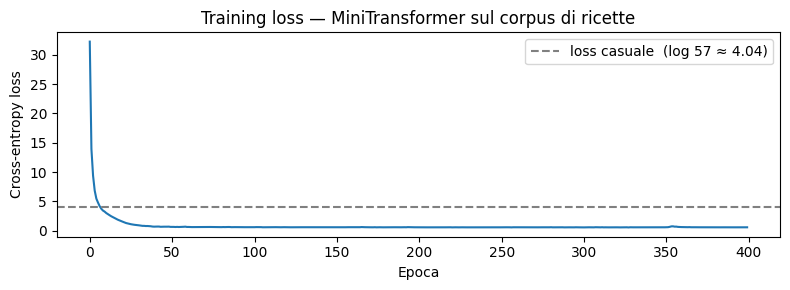

In [22]:
N_EPOCHS = 400
LR       = 3e-3

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)

losses = []
model.train()
for epoch in range(N_EPOCHS):
    epoch_loss = 0.0
    for x_batch, y_batch in dataloader:
        logits = model(x_batch)                             # (B, T, vocab_size)
        loss = F.cross_entropy(
            logits.view(-1, tokenizer.vocab_size),
            y_batch.view(-1),
            ignore_index=Tokenizer.PAD_IDX,
        )
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    losses.append(epoch_loss / len(dataloader))
    if (epoch + 1) % 50 == 0:
        print(f"  epoch {epoch+1:4d}  |  loss = {losses[-1]:.4f}")

# Salvataggio
save_path = Path('./data/mini_transformer.pt')
torch.save({
    'model_state': model.state_dict(),
    'config': dict(vocab_size=tokenizer.vocab_size, d_model=D_MODEL,
                   n_heads=N_HEADS, d_ff=D_FF, n_layers=N_LAYERS,
                   context_len=context_len),
}, save_path)
print(f"\nModello salvato → {save_path}")

# Curva di training
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(losses)
ax.set_xlabel('Epoca'); ax.set_ylabel('Cross-entropy loss')
ax.set_title('Training loss — MiniTransformer sul corpus di ricette')
ax.axhline(math.log(tokenizer.vocab_size), color='gray', linestyle='--',
           label=f'loss casuale  (log {tokenizer.vocab_size} ≈ {math.log(tokenizer.vocab_size):.2f})')
ax.legend(); plt.tight_layout(); plt.show()

### Dalla distribuzione alla predizione: greedy vs campionamento

Il modello produce per ogni posizione un vettore di **logit** — valori reali non
normalizzati, uno per token del vocabolario. Il softmax li converte in probabilità:

```
probs = softmax(logits / T)
```

Il parametro **temperatura** T riscala i logit prima del softmax:

- **T → 0** (greedy): la probabilità si concentra tutta sul token con logit massimo.
  Ogni chiamata produce lo stesso risultato — nessuna casualità.
- **T = 1** (sampling standard): si campiona dalla distribuzione originale.
- **T > 1**: i logit vengono compressi, la distribuzione diventa più piatta —
  token meno probabili hanno più chance di essere estratti.

Dividere per T non cambia quale token ha la probabilità massima, ma cambia
quanto è dominante rispetto agli altri:

```
T bassa  →  distribuzione peaked  →  predizioni ripetibili, conservative
T alta   →  distribuzione flat    →  predizioni varie, a volte sorprendenti
```

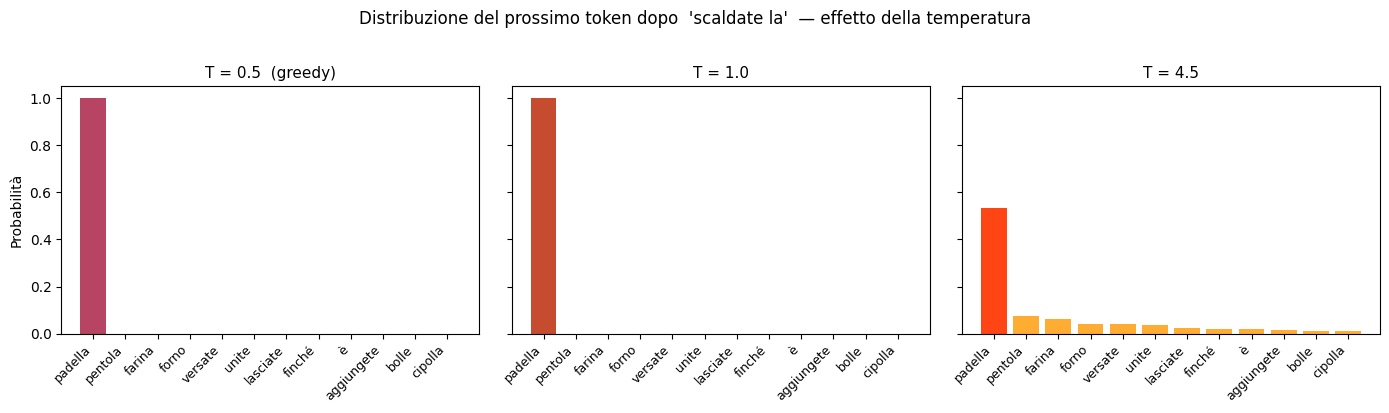

In [27]:
probe_prompt = 'scaldate la'
probe_idx = torch.tensor(tokenizer.encode(probe_prompt)).unsqueeze(0)
TOP_K = 12

with torch.no_grad():
    logits_probe = model(probe_idx)[0, -1]   # logit per il token dopo 'scaldate la'

temperatures = [0.5, 1.0, 4.5]
probs_by_temp = {t: F.softmax(logits_probe / t, dim=-1) for t in temperatures}

# Top-K token dalla distribuzione a T=1 (ordine fisso per tutti i pannelli)
top_idx = probs_by_temp[1.0].topk(TOP_K).indices.tolist()
top_labels = [tokenizer.idx2word[i] for i in top_idx]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
colors = ['#2196F3', '#4CAF50', '#FF9800']
for ax, T, color in zip(axes, temperatures, colors):
    vals = [probs_by_temp[T][i].item() for i in top_idx]
    bars = ax.bar(range(TOP_K), vals, color=color, alpha=0.8)
    ax.set_xticks(range(TOP_K))
    ax.set_xticklabels(top_labels, rotation=45, ha='right', fontsize=9)
    ax.set_title(f'T = {T}{"  (greedy)" if T == 0.5 else ""}', fontsize=11)
    ax.set_ylabel('Probabilità' if ax is axes[0] else '')
    # annotate top bar
    top_local = max(range(TOP_K), key=lambda i: vals[i])
    ax.bar(top_local, vals[top_local], color='red', alpha=0.6)

plt.suptitle(f"Distribuzione del prossimo token dopo  '{probe_prompt}'  — effetto della temperatura",
             y=1.02)
plt.tight_layout()
plt.show()

In [30]:
N_RUNS = 8

print(f"Prompt: '{probe_prompt}'\n")

print(f"{'─'*55}")
print(f"Greedy (T → 0) — {N_RUNS} estrazioni:")
greedy_outs = [model.generate(probe_prompt, tokenizer, greedy=True) for _ in range(N_RUNS)]
for out in greedy_outs:
    print(f"  {out}")
print(f"  → {len(set(greedy_outs))} risultato/i distinto/i su {N_RUNS}")

for T in [1.0, 4.5]:
    print(f"\n{'─'*55}")
    print(f"Sampling T = {T} — {N_RUNS} estrazioni:")
    torch.manual_seed(0)
    sampled = [model.generate(probe_prompt, tokenizer, temperature=T) for _ in range(N_RUNS)]
    for out in sampled:
        print(f"  {out}")
    print(f"  → {len(set(sampled))} risultati distinti su {N_RUNS}")

Prompt: 'scaldate la'

───────────────────────────────────────────────────────
Greedy (T → 0) — 8 estrazioni:
  scaldate la padella poi versate l'olio .
  scaldate la padella poi versate l'olio .
  scaldate la padella poi versate l'olio .
  scaldate la padella poi versate l'olio .
  scaldate la padella poi versate l'olio .
  scaldate la padella poi versate l'olio .
  scaldate la padella poi versate l'olio .
  scaldate la padella poi versate l'olio .
  → 1 risultato/i distinto/i su 8

───────────────────────────────────────────────────────
Sampling T = 1.0 — 8 estrazioni:
  scaldate la padella finché l'olio è caldo .
  scaldate la padella finché è calda .
  scaldate la padella a fuoco lento .
  scaldate la padella a fuoco lento .
  scaldate la padella poi aggiungete l'aglio .
  scaldate la padella poi versate l'olio lentamente .
  scaldate la padella .
  scaldate la padella e versate l'olio .
  → 7 risultati distinti su 8

───────────────────────────────────────────────────────
Sampling

In [31]:
# Generazione autoregressiva da diversi prompt
prompts = [
    'scaldate',
    'tagliate la',
    'versate',
    'lasciate cuocere',
    'aggiungete il',
]

print("=== Greedy decoding (temperatura = 0) ===")
for p in prompts:
    out = model.generate(p, tokenizer, max_new_tokens=10, greedy=True)
    print(f"  [{p}]  →  {out}")

print("\n=== Sampling (temperatura = 0.8) ===")
torch.manual_seed(99)
for p in prompts:
    out = model.generate(p, tokenizer, max_new_tokens=10, temperature=0.8)
    print(f"  [{p}]  →  {out}")

=== Greedy decoding (temperatura = 0) ===
  [scaldate]  →  scaldate il latte lentamente finché bolle .
  [tagliate la]  →  tagliate la cipolla piano e cuocete nella padella .
  [versate]  →  versate il vino poi cuocete finché è caldo .
  [lasciate cuocere]  →  lasciate cuocere finché il latte è caldo .
  [aggiungete il]  →  aggiungete il burro e mescolate finché fonde .

=== Sampling (temperatura = 0.8) ===
  [scaldate]  →  scaldate il forno quindi aggiungete le uova .
  [tagliate la]  →  tagliate la cipolla piano e cuocete nella padella .
  [versate]  →  versate l'olio nella padella e scaldate lentamente .
  [lasciate cuocere]  →  lasciate cuocere finché il latte è caldo .
  [aggiungete il]  →  aggiungete il burro e mescolate finché fonde .


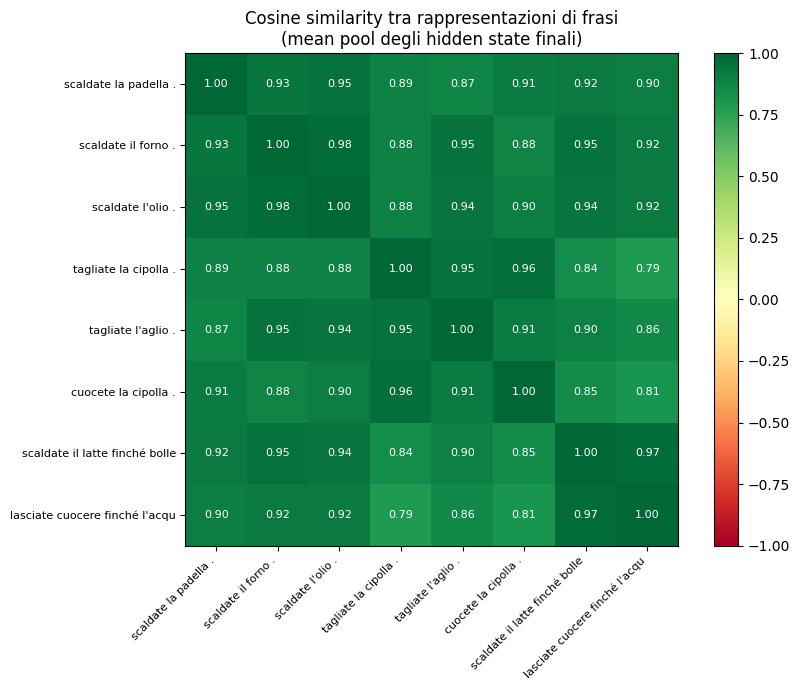

In [32]:
# Rappresentazioni vettoriali delle frasi (mean pooling sull'ultimo layer)
probe_sentences = [
    # azioni simili
    'scaldate la padella .',
    'scaldate il forno .',
    'scaldate l\'olio .',
    # strutture diverse
    'tagliate la cipolla .',
    'tagliate l\'aglio .',
    'cuocete la cipolla .',
    # frasi con finché
    'scaldate il latte finché bolle .',
    'lasciate cuocere finché l\'acqua bolle .',
]

vecs = torch.stack([model.encode_sentence(s, tokenizer) for s in probe_sentences])
vecs_norm = vecs / vecs.norm(dim=-1, keepdim=True)
sim = (vecs_norm @ vecs_norm.T).detach().numpy()

labels = [s[:30] for s in probe_sentences]

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(sim, cmap='RdYlGn', vmin=-1, vmax=1)
for i in range(len(probe_sentences)):
    for j in range(len(probe_sentences)):
        ax.text(j, i, f'{sim[i,j]:.2f}', ha='center', va='center', fontsize=8,
                color='black' if abs(sim[i,j]) < 0.7 else 'white')
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=8)
ax.set_title('Cosine similarity tra rappresentazioni di frasi\n(mean pool degli hidden state finali)')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()